We start by picking a random seed so that every time we reproduce the code, the results are not affected by random factors.

In [1]:
SEED = 158

Next we load the dataset from the databse.

In [2]:
import pandas as pd
from datasets import load_dataset, DatasetDict, Dataset, DatasetInfo

splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
ds = pd.read_parquet("hf://datasets/ailsntua/QEvasion/" + splits["train"])
train = ds
test = pd.read_parquet("hf://datasets/ailsntua/QEvasion/" + splits["test"])

ds

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,85,None,None,None,False,False,False,0,Clear Reply,Explicit
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,85,None,None,None,False,False,False,1,Ambivalent,General
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,85,None,None,None,False,False,False,2,Ambivalent,Partial/half-answer
3,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Are you worried about the meeting between Pre...,85,None,None,None,False,False,False,3,Ambivalent,Dodging
4,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,3,"Q. I can imagine. It is evening, I'd like to r...","Well, I hope I get to see Mr. Xi sooner than l...",The question consists of 3 parts:\n1. Is the P...,Question part: 1. Is the President's engagemen...,Is the President's engagement with Asian coun...,85,None,None,None,False,False,False,4,Clear Reply,Explicit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3443,The President's News Conference,"October 25, 2006",George W. Bush,https://www.presidency.ucsb.edu/documents/the-...,16,"Q. Thank you, Mr. President. With a Republican...",That's a tricky little question there. [] Firs...,The question consists of 1 part:\n\n1. Why sho...,Question part: 1 - Why shouldn't Americans giv...,Why shouldn't Americans give Democrats a chan...,86,None,None,None,False,False,False,3443,Ambivalent,Deflection
3444,The President's News Conference,"October 25, 2006",George W. Bush,https://www.presidency.ucsb.edu/documents/the-...,17,"Q. I just wanted to ask you quickly, sir, if y...","Mike, I believe Iraq will be able to defend, g...",The question consists of 1 part:\n\n1. Inquiry...,Question part: 1. Belief about Iraq's ability ...,Inquiry about the belief regarding the abilit...,89,None,None,None,False,False,True,3444,Clear Reply,Explicit
3445,The President's News Conference,"October 25, 2006",George W. Bush,https://www.presidency.ucsb.edu/documents/the-...,18,Q. I understand why you would claim or assert ...,"You know, no, I'm not resentful, nor am I rese...",The question consists of 2 parts:\n\n1. If you...,Question part: 1. If you really didn't think t...,Are you resentful that some Republican candid...,89,None,None,None,False,False,False,3445,Clear Reply,Explicit
3446,The President's News Conference,"October 25, 2006",George W. Bush,https:/

Now using the pandas library we will take a look at the distribution of our data in order to get a picture of the situation.

In [3]:
df_train: pd.DataFrame = pd.DataFrame(load_dataset("ailsntua/QEvasion", split='train'))
clarity_column: pd.Series = df_train['clarity_label']
clarity_column.value_counts()

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

clarity_label
Ambivalent         2040
Clear Reply        1052
Clear Non-Reply     356
Name: count, dtype: int64

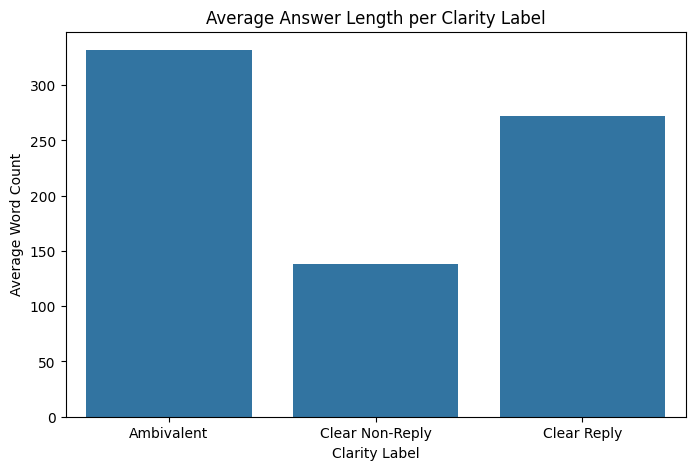

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

train["answer_length"] = train["interview_answer"].apply(lambda x: len(x.split()))

avg_lengths = train.groupby("clarity_label")["answer_length"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_lengths, x="clarity_label", y="answer_length")
plt.title("Average Answer Length per Clarity Label")
plt.xlabel("Clarity Label")
plt.ylabel("Average Word Count")
plt.show()

> From the results of the two previous cells of code we make two observations. Firstly, the database has double the 'Ambivalent' answers to the 'Clear Reply' ones, which in succession are also double to the 'Clear Non-Reply' ones. This will be used later to calculate the F1 score. Secondly, we see that 'Ambivalent' answers have more words on avarage than the rest, while 'Clear Non-Reply' have by far the lowest. This might be important later on.

Now we must prepare the data by combining the questions and answers to one single entry.

In [5]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt

train["input_text"] = train["question"] + " [SEP] " + train["interview_answer"]
test["input_text"] = test["question"] + " [SEP] " + test["interview_answer"]

train.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,...,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label,answer_length,input_text
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,...,None,None,False,False,False,0,Clear Reply,Explicit,359,How would you respond to the accusation that t...
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,...,None,None,False,False,False,1,Ambivalent,General,359,Do you think President Xi is being sincere abo...
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,...,None,None,False,False,False,2,Ambivalent,Partial/half-answer,219,Do you believe the country's slowdown and gro...


Create the train and validation data.

In [6]:
X = train["input_text"]
Y = train["clarity_label"]

X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, Y,test_size=0.15,random_state=SEED,stratify=Y)

> a) Model trainig using TF-IDF

We keep the maximum at 10000 so that we do not have an excesive ammount of features and the range to 5.

In [7]:
tfidf = TfidfVectorizer(max_features=100000, ngram_range=(1,5))

from scipy.sparse import hstack, csr_matrix

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_val_tfidf   = tfidf.transform(X_val_raw)
X_test_tfidf  = tfidf.transform(test["input_text"])

Now we see the progression of our model while it trains to the data. Each time we give the model access to more data in order to see paterns such as overfitting.

10% training data — Train F1: 0.96 | Val F1: 0.38
20% training data — Train F1: 0.94 | Val F1: 0.43
30% training data — Train F1: 0.92 | Val F1: 0.43
40% training data — Train F1: 0.91 | Val F1: 0.45
50% training data — Train F1: 0.89 | Val F1: 0.47
60% training data — Train F1: 0.88 | Val F1: 0.49
70% training data — Train F1: 0.88 | Val F1: 0.52
80% training data — Train F1: 0.87 | Val F1: 0.55
90% training data — Train F1: 0.86 | Val F1: 0.55
100% training data — Train F1: 0.85 | Val F1: 0.57


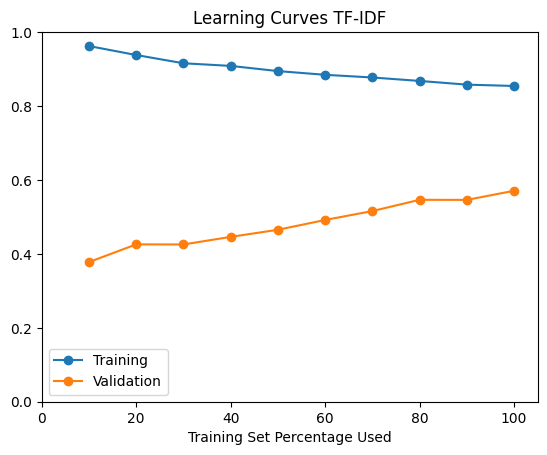

In [8]:
list_f1_val = []
list_f1_train = []
list_sample_size = []

custom_weights = {"Ambivalent":1, "Clear Non-Reply":2, "Clear Reply":2.5}

for times in range(1, 10):
    
    X_subset, _, y_subset, _ = train_test_split(X_train_tfidf,y_train,test_size=1 - (times * 0.1),random_state=SEED,stratify=y_train)

    clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight=custom_weights, C=1)
    clf.fit(X_subset, y_subset)

    results_train = clf.predict(X_subset)
    results_val   = clf.predict(X_val_tfidf)

    f1_train = f1_score(y_subset, results_train, average="macro")
    f1_val   = f1_score(y_val, results_val,   average="macro")

    print(f"{int(times * 10)}% training data — Train F1: {f1_train:.2f} | Val F1: {f1_val:.2f}")

    list_f1_train.append(f1_train)
    list_f1_val.append(f1_val)
    list_sample_size.append(times * 10)

clf_full = LogisticRegression(max_iter=1000, random_state=SEED, class_weight=custom_weights, C=1)
clf_full.fit(X_train_tfidf, y_train)

f1_train_full = f1_score(y_train, clf_full.predict(X_train_tfidf), average="macro")
f1_val_full   = f1_score(y_val,   clf_full.predict(X_val_tfidf),   average="macro")

print(f"100% training data — Train F1: {f1_train_full:.2f} | Val F1: {f1_val_full:.2f}")

list_f1_train.append(f1_train_full)
list_f1_val.append(f1_val_full)
list_sample_size.append(100)

plt.plot(list_sample_size, list_f1_train, marker="o")
plt.plot(list_sample_size, list_f1_val,   marker="o")
plt.title("Learning Curves TF-IDF")
plt.xlabel("Training Set Percentage Used")
plt.xlim(0, 105)
plt.ylim(0, 1)
plt.legend(["Training", "Validation"])

As we see the model does overfit as it performs better at the training set than in the validation set.

> b) Model training using Word2Vec

Loading the model format. The original google news source was not working so it was directly downloaded from gensim.

In [9]:
import gensim.downloader as api

wv = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


Using the avaraging function we defined we give each word the correct vector according to the wv format, skipping the words that are missing. This ensures that we have the data prepared and ready to train our model.

In [10]:
def average_vector(text, keyed_vectors):
    words = text.split()
    vectors = [keyed_vectors[w] for w in words if w in keyed_vectors]  
    return np.mean(vectors, axis=0) if vectors else np.zeros(keyed_vectors.vector_size)

X_train_w2v = np.array([average_vector(t, wv) for t in X_train_raw])
X_val_w2v   = np.array([average_vector(t, wv) for t in X_val_raw])
X_test_w2v  = np.array([average_vector(t, wv) for t in test["input_text"]])

Once again we see the progression of our model while it trains to the data.

10% training data — Train F1: 0.64 | Val F1: 0.44
20% training data — Train F1: 0.56 | Val F1: 0.40
30% training data — Train F1: 0.54 | Val F1: 0.44
40% training data — Train F1: 0.54 | Val F1: 0.43
50% training data — Train F1: 0.55 | Val F1: 0.44
60% training data — Train F1: 0.53 | Val F1: 0.44
70% training data — Train F1: 0.53 | Val F1: 0.45
80% training data — Train F1: 0.52 | Val F1: 0.45
90% training data — Train F1: 0.51 | Val F1: 0.45
100% training data — Train F1: 0.52 | Val F1: 0.48


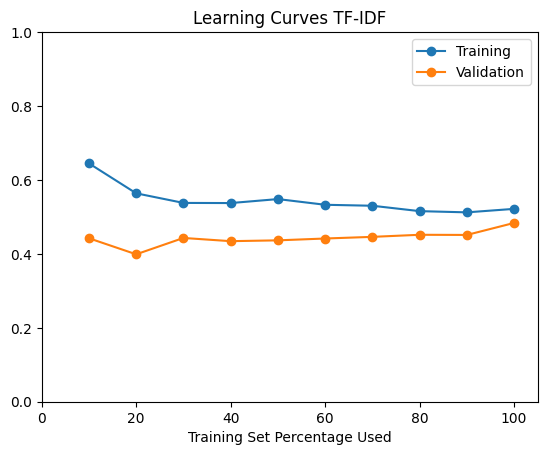

In [11]:
list_f1_val = []
list_f1_train = []
list_sample_size = []

for times in range(1, 10):
    
    X_subset, _, y_subset, _ = train_test_split(X_train_w2v,y_train,test_size=1 - (times * 0.1),random_state=SEED,stratify=y_train)

    clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced", C=1)
    clf.fit(X_subset, y_subset)
    
    results_train = clf.predict(X_subset)
    results_val   = clf.predict(X_val_w2v)

    f1_train = f1_score(y_subset, results_train, average="macro")
    f1_val   = f1_score(y_val, results_val,   average="macro")

    print(f"{int(times * 10)}% training data — Train F1: {f1_train:.2f} | Val F1: {f1_val:.2f}")

    list_f1_train.append(f1_train)
    list_f1_val.append(f1_val)
    list_sample_size.append(times * 10)

clf_full = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced", C=1)
clf_full.fit(X_train_w2v, y_train)

f1_train_full = f1_score(y_train, clf_full.predict(X_train_w2v), average="macro")
f1_val_full   = f1_score(y_val,   clf_full.predict(X_val_w2v),   average="macro")

print(f"100% training data — Train F1: {f1_train_full:.2f} | Val F1: {f1_val_full:.2f}")

list_f1_train.append(f1_train_full)
list_f1_val.append(f1_val_full)
list_sample_size.append(100)

plt.plot(list_sample_size, list_f1_train, marker="o")
plt.plot(list_sample_size, list_f1_val,   marker="o")
plt.title("Learning Curves TF-IDF")
plt.xlabel("Training Set Percentage Used")
plt.xlim(0, 105)
plt.ylim(0, 1)
plt.legend(["Training", "Validation"])

This time the model does not show patterns of overfitting, but the validation results are worse than the ones before. Now we can directly compare both models trained on 100% of the data to decide which is better.

In [12]:
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)


lr_tfidf = LogisticRegression(max_iter=1000,random_state=SEED,class_weight="balanced")
lr_tfidf.fit(X_train_tfidf, y_train_enc)

print("=== TF-IDF ===")
y_val_pred_tfidf = lr_tfidf.predict(X_val_tfidf)
print(classification_report(y_val_enc, y_val_pred_tfidf, target_names=le.classes_))


lr_w2v = LogisticRegression(max_iter=1000,random_state=SEED,class_weight="balanced")
lr_w2v.fit(X_train_w2v, y_train_enc)

print("=== W2V ===")
y_val_pred_w2v = lr_w2v.predict(X_val_w2v)
print(classification_report(y_val_enc, y_val_pred_w2v, target_names=le.classes_))

=== TF-IDF ===
                 precision    recall  f1-score   support

     Ambivalent       0.70      0.65      0.67       306
Clear Non-Reply       0.48      0.63      0.54        54
    Clear Reply       0.48      0.49      0.48       158

       accuracy                           0.60       518
      macro avg       0.55      0.59      0.57       518
   weighted avg       0.61      0.60      0.60       518

=== W2V ===
                 precision    recall  f1-score   support

     Ambivalent       0.68      0.67      0.67       306
Clear Non-Reply       0.32      0.56      0.41        54
    Clear Reply       0.43      0.33      0.37       158

       accuracy                           0.55       518
      macro avg       0.47      0.52      0.48       518
   weighted avg       0.56      0.55      0.55       518



The results clearly show that despite the overfitting, TF-IDF wins on every metric, macro f1-score, macro precision, macro recall and accuracy are better. In conclusion, we keep the TF-IDF model for our final agent.

In [13]:
test_preds  = lr_tfidf.predict(X_test_tfidf)
test_labels = le.inverse_transform(test_preds)

test_labels

array(['Clear Reply', 'Ambivalent', 'Ambivalent', 'Ambivalent',
       'Ambivalent', 'Ambivalent', 'Ambivalent', 'Ambivalent',
       'Ambivalent', 'Ambivalent', 'Ambivalent', 'Ambivalent',
       'Ambivalent', 'Ambivalent', 'Clear Reply', 'Ambivalent',
       'Clear Non-Reply', 'Clear Non-Reply', 'Ambivalent', 'Clear Reply',
       'Ambivalent', 'Ambivalent', 'Ambivalent', 'Ambivalent',
       'Ambivalent', 'Ambivalent', 'Ambivalent', 'Ambivalent',
       'Ambivalent', 'Ambivalent', 'Ambivalent', 'Ambivalent',
       'Ambivalent', 'Ambivalent', 'Clear Reply', 'Clear Reply',
       'Clear Reply', 'Ambivalent', 'Ambivalent', 'Ambivalent',
       'Ambivalent', 'Ambivalent', 'Ambivalent', 'Ambivalent',
       'Clear Reply', 'Ambivalent', 'Ambivalent', 'Clear Reply',
       'Ambivalent', 'Clear Reply', 'Ambivalent', 'Clear Reply',
       'Ambivalent', 'Ambivalent', 'Ambivalent', 'Clear Reply',
       'Clear Non-Reply', 'Ambivalent', 'Ambivalent', 'Clear Reply',
       'Clear Reply', 'Clear

Final submission of the assignment.

In [14]:
submission = pd.DataFrame({
    "Id": test["index"],
    "Predicted": test_labels
})

submission.to_csv("submission.csv", index=False)
print("Submission completed.")

Submission completed.
